# Classifying *Manifest* Fandom Posts

This notebook fine-tunes a DistilBERT text classifier on a hand-labeled dataset of *Manifest* TV-fandom posts and compares it against a zero-shot Groq baseline. It loads and validates the dataset, splits and tokenizes it, fine-tunes the model, evaluates on a held-out test set (metrics + confusion matrix), then runs the baseline for comparison.

Runtime: T4 GPU (Runtime → Change runtime type → T4 GPU).

In [1]:
# Install dependencies
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## 1. Load the dataset

Loads the labeled CSV and defines the label map. The dataset has `text` and `label` columns, with three labels: `theory`, `rant_rave`, and `plot_question`.

In [3]:
LABEL_MAP = {
    "theory":  0,   # outlines a structured hypothesis about the show's mysteries
    "rant_rave":  1,   # emotional reaction focusing entirely on liking or disliking a specific character, relationship, or plot point
    "plot_question":  2,   # straightforward, factual question about something the viewer missed or found confusing in the timeline or episodes
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

'''
This community centers on the Manifest television series fandom,
where passionate viewers dissect the show's complex lore,
character arcs, and supernatural mysteries. The taxonomy
categorizes discourse into structured fan theories, emotional
character or plot rants, and factual timeline questions.
Distinguishing between these styles of engagement matters
deeply to community members because it separates rigorous
narrative puzzle-solving from raw emotional reactions and
surface-level viewer confusion.
'''

Labels: {'theory': 0, 'rant_rave': 1, 'plot_question': 2}
Number of labels: 3


"\nThis community centers on the Manifest television series fandom,\nwhere passionate viewers dissect the show's complex lore,\ncharacter arcs, and supernatural mysteries. The taxonomy\ncategorizes discourse into structured fan theories, emotional\ncharacter or plot rants, and factual timeline questions.\nDistinguishing between these styles of engagement matters\ndeeply to community members because it separates rigorous\nnarrative puzzle-solving from raw emotional reactions and\nsurface-level viewer confusion.\n"

In [4]:
# Upload the dataset CSV
from google.colab import files
print("Select the labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving manifest_reviews.csv to manifest_reviews.csv
Uploaded: manifest_reviews.csv


In [5]:
# Load and validate the dataset
df = pd.read_csv(CSV_PATH)

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Check every label is in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠\ufe0f  Labels in CSV not found in LABEL_MAP: {unknown}")
else:
    print("\n✅ All labels match LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'source', 'notes']
Total examples: 210

Label distribution:
label
plot_question    72
rant_rave        70
theory           68
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## 2. Prepare the data

Splits the dataset 70/15/15 into train/validation/test (stratified by label) and tokenizes the text.

In [6]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 147 examples
Validation: 31 examples
Test: 32 examples

Train label distribution:
label
plot_question    50
rant_rave        49
theory           48
Name: count, dtype: int64

Test label distribution:
label
rant_rave        11
plot_question    11
theory           10
Name: count, dtype: int64


In [7]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/147 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Map:   0%|          | 0/32 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## 3. Fine-tune DistilBERT

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on the training set. I trained for 8 epochs — see the note in the training cell for why.

In [22]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [24]:
# Training configuration.
# I increased num_train_epochs from a default of 3 to 8: at 3 epochs the model
# was undertrained and sat near the 3-class random floor, collapsing uncertain
# posts into a single label. At 8 epochs validation accuracy climbed to ~0.97
# with no overfitting (validation loss was still falling). Learning rate, batch
# size, and weight decay are standard DistilBERT fine-tuning values.
training_args = TrainingArguments(
    output_dir="./manifest-classifier-model",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.118156,1.110543,0.322581
2,1.106465,1.091194,0.322581
3,1.082853,1.021637,0.709677
4,0.985326,0.870875,0.774194
5,0.839392,0.676559,0.870968
6,0.650842,0.483185,0.935484
7,0.430044,0.384752,0.935484
8,0.374295,0.343308,0.967742


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## 4. Evaluate on the test set

Runs inference on the held-out test set and produces overall accuracy, per-class metrics, and a confusion matrix.

In [25]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.906

Per-class metrics (fine-tuned model):
               precision    recall  f1-score   support

       theory       0.90      0.90      0.90        10
    rant_rave       0.91      0.91      0.91        11
plot_question       0.91      0.91      0.91        11

     accuracy                           0.91        32
    macro avg       0.91      0.91      0.91        32
 weighted avg       0.91      0.91      0.91        32



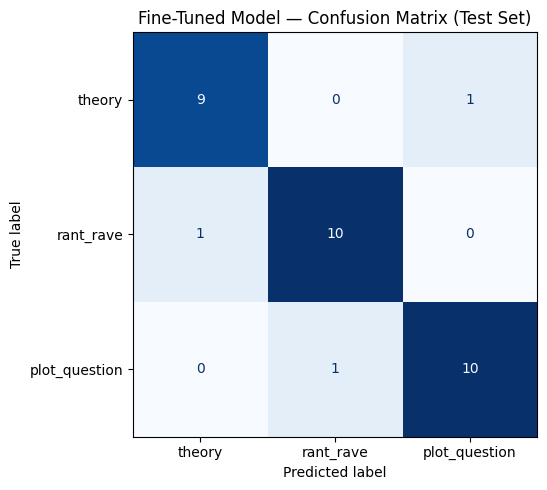

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [26]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved confusion_matrix.png")

In [27]:
# Wrong predictions (for error analysis)
wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 3 / 32

--- #1 ---
Text:      No spoilers but didnt they drastically change her storyline due to the hate the real life character was getting?
True:      plot_question
Predicted: rant_rave  (confidence: 0.45)

--- #2 ---
Text:      I was hoping it would be a sci fi show or that the government was involved in what happened.
True:      rant_rave
Predicted: theory  (confidence: 0.44)

--- #3 ---
Text:      And what if Al-Zuras' ship wasn't sailing in the ocean but ON THE FLOOD that happened with Noah? Maybe they crossed paths. It's all possible and it's all connected ✌️✌️
True:      theory
Predicted: plot_question  (confidence: 0.61)



In [28]:
import numpy as np
correct_idx = np.where(ft_pred_ids == ft_true_ids)[0]
# highest-confidence correct predictions
order = sorted(correct_idx, key=lambda i: ft_probs[i][ft_pred_ids[i]], reverse=True)
for i in order[:4]:
    label = ID_TO_LABEL[ft_pred_ids[i]]
    conf  = ft_probs[i][ft_pred_ids[i]]
    print(f"[{label}  conf {conf:.2f}]  {test_df.iloc[i]['text'][:140]}")

[plot_question  conf 0.91]  Did the Exxers just dissapear? What happened to them?
[plot_question  conf 0.91]  Does Eden have a death date?
[plot_question  conf 0.91]  At the end, what happened to Ben and Mick's father at the cabin? Did I miss that?
[plot_question  conf 0.90]  What is Tyson doing in Egypt?


---
## 5. Zero-shot baseline (Groq)

Runs a zero-shot baseline with `llama-3.3-70b-versatile` using the classification prompt below, to compare against the fine-tuned model.

In [8]:
from groq import Groq
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

assert GROQ_API_KEY, "GROQ_API_KEY not set — add it in the Colab Secrets panel and enable notebook access."

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [9]:
SYSTEM_PROMPT = """
You are classifying posts from the Manifest TV-show fandom on Reddit.
Manifest is a mystery drama; fans post about the show in different ways.
Assign each post to exactly one of the following three categories.

theory: a post that lays out a hypothesis or prediction about the show's mysteries.
Example: "My theory is God wanted to test humanity and chose those in 828 as a sample set to decide whether to cause an apocalypse"

rant_rave: a post that is mainly an emotional reaction — liking or disliking a character, relationship, or plot point.
Example: "This show is so freaking bland and Grace is so annoying that I couldn't even finish season 2."

plot_question: a factual question about something the viewer missed or found confusing.
Example: "Why did Cal age when he was gone?"

Rules for hard cases — judge by the post's MAIN PURPOSE, not its punctuation:
- A question that is really arguing a point is theory, not plot_question.
- A complaint shaped like a question (venting, not seeking an answer) is rant_rave.
- An emotional post that still makes a real claim is theory; if removing the emotion leaves nothing, it is rant_rave.

Respond with ONLY the label name — exactly one of: theory, rant_rave, plot_question.
Do not add punctuation, quotes, or any explanation.

Valid labels:
theory
rant_rave
plot_question
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1326 characters


In [10]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match output to a label; check longest labels first so a label that is
        # a substring of another can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠\ufe0f  {none_count} responses could not be parsed.")

Running baseline on 32 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/32 complete...
  20/32 complete...
  30/32 complete...


In [11]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.875  (evaluated on 32/32 parseable responses)

Per-class metrics (baseline):
               precision    recall  f1-score   support

       theory       0.91      1.00      0.95        10
    rant_rave       0.79      1.00      0.88        11
plot_question       1.00      0.64      0.78        11

     accuracy                           0.88        32
    macro avg       0.90      0.88      0.87        32
 weighted avg       0.90      0.88      0.87        32



---
## 6. Compare and export

Side-by-side accuracy comparison, and saves the metrics and confusion matrix.

In [29]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.875
Fine-tuned DistilBERT                  0.906
---------------------------------------------

Fine-tuning improvement: 0.031

Use these numbers in your README evaluation report.


In [30]:
# Save results to JSON
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Saved evaluation_results.json and confusion_matrix.png")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
